# Assignment 3 — SQLite Database Design, Population & Analysis
## New Zealand Supermarket Price Trends & Cost-of-Living Pressure

**Student name:** Linxin Guo

**Student ID:**  26004351

---
This notebook implements **Assignment 3**: designing a normalised SQLite relational database schema, populating it from the datasets acquired in Assignment 4, and performing complex SQL-based analysis with joins, aggregations, subqueries, and views.

---
## 1. Import Libraries

In [469]:
# ── Core libraries (as taught in lectures) ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import datetime as dt
import warnings
from pylab import rcParams
from IPython.display import Image, display

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 60)
rcParams['figure.figsize'] = 14, 6
rcParams['font.size'] = 13
rcParams['axes.facecolor'] = 'white'
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.4
sns.set(style='ticks')
%matplotlib inline
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


> ✅ **Result:** All libraries imported without errors — the environment is ready for database operations, data manipulation, and visualisation.

---
## 2. Database Schema Design

### 2.1 High-Level Description

The database is designed in **Third Normal Form (3NF)** to eliminate data redundancy and ensure referential integrity. It captures grocery price data from three NZ supermarket chains across three data sources.

**Six normalised tables:**

| Table | Description | Key Relationships |
|-------|-------------|-------------------|
| `stores` | Master list of the 3 supermarket chains | Referenced by `raw_prices`, `basket_prices` |
| `categories` | Product category master (Dairy, Bakery, etc.) | Referenced by `raw_prices`, `basket_items` |
| `raw_prices` | Individual scraped product prices from live websites | FK (foreign key) → `stores`, `categories` |
| `basket_items` | 20 standardised grocery basket items | FK → `categories` |
| `basket_prices` | Quarterly price per basket item per store (2021–2024) | FK → `stores`, `basket_items` |
| `cpi_food` | Annual World Bank food CPI index for New Zealand | Joined analytically on `year` |

**Design decisions:**
- `stores` and `categories` are extracted as separate dimension tables to avoid repeating metadata in every fact row
- `basket_items` separates item metadata from the transactional `basket_prices` table
- `FOREIGN KEY` constraints enforce referential integrity between all related tables
- `NOT NULL` constraints are applied to all required fields
- `UNIQUE` constraints prevent duplicate master records
- `CHECK` constraints validate data ranges (e.g. prices must be ≥ 0)
- Indexes are created on all FK columns and frequently filtered columns to speed up joins

### 2.2 Database Schema Diagram

The diagram below was generated using **DBSchema** (https://dbschema.com/). It shows all 6 tables, their columns, primary keys, foreign keys, and the relationships between tables.


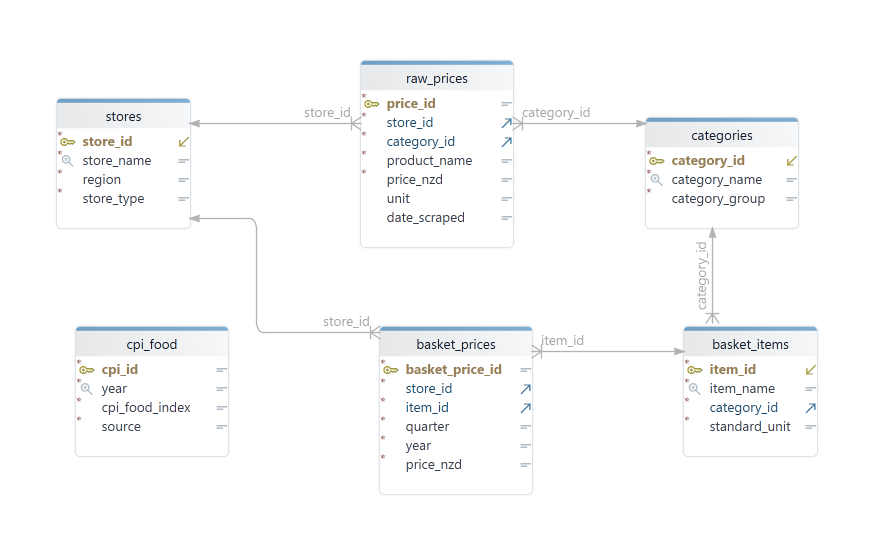

In [470]:
# Display the DBSchema ER diagram embedded in the notebook
display(Image(filename='diagram.png', width=820))

---
## 3. Database Schema Code — Creating All Tables

All tables are created using SQLite3. Foreign keys are enabled with `PRAGMA foreign_keys = ON`.

In [471]:
# ── Connect to SQLite database (creates file if it doesn't exist) ─────────────
# sqlite3.connect() creates or opens a .db file
connection = sqlite3.connect('nz_supermarket_a3.db')
cursor = connection.cursor()

# Enable foreign key constraint enforcement (required each connection in SQLite)
cursor.execute('PRAGMA foreign_keys = ON;')
connection.commit()

print('Connected to: nz_supermarket_a3.db')

Connected to: nz_supermarket_a3.db


>  A live connection to `nz_supermarket_a3.db` is established and foreign key enforcement is active for this session.

In [472]:
# ── DROP existing tables in reverse dependency order (safe re-run) ────────────
drop_statements = [
    'DROP VIEW  IF EXISTS v_quarterly_basket_cost;',
    'DROP VIEW  IF EXISTS v_store_category_avg;',
    'DROP TABLE IF EXISTS basket_prices;',
    'DROP TABLE IF EXISTS basket_items;',
    'DROP TABLE IF EXISTS raw_prices;',
    'DROP TABLE IF EXISTS cpi_food;',
    'DROP TABLE IF EXISTS stores;',
    'DROP TABLE IF EXISTS categories;',
]
for stmt in drop_statements:
    cursor.execute(stmt)
connection.commit()
print('Existing tables and views dropped cleanly.')

Existing tables and views dropped cleanly.


> All pre-existing tables and views are cleared. The notebook can be re-run from scratch without manual cleanup or duplicate-key errors.

In [473]:
# ─────────────────────────────────────────────────────────────────────────────
# TABLE 1: stores
# Dimension table — one row per supermarket chain.
# store_name is UNIQUE to prevent inserting the same store twice.
# ─────────────────────────────────────────────────────────────────────────────
sql_create_stores = """
    CREATE TABLE stores (
        store_id   INTEGER PRIMARY KEY AUTOINCREMENT,
        store_name TEXT    NOT NULL UNIQUE,
        region     TEXT    NOT NULL DEFAULT 'New Zealand',
        store_type TEXT    NOT NULL DEFAULT 'Supermarket'
    );
"""

# ─────────────────────────────────────────────────────────────────────────────
# TABLE 2: categories
# Dimension table — product categories normalised out of raw_prices.
# Storing category metadata once avoids repeating it in every price row.
# ─────────────────────────────────────────────────────────────────────────────
sql_create_categories = """
    CREATE TABLE categories (
        category_id    INTEGER PRIMARY KEY AUTOINCREMENT,
        category_name  TEXT    NOT NULL UNIQUE,
        category_group TEXT    NOT NULL
    );
"""

# ─────────────────────────────────────────────────────────────────────────────
# TABLE 3: raw_prices
# Fact table — individual product prices from live web scraping (Source 1).
# CHECK constraint ensures prices are non-negative.
# ─────────────────────────────────────────────────────────────────────────────
sql_create_raw_prices = """
    CREATE TABLE raw_prices (
        price_id     INTEGER PRIMARY KEY AUTOINCREMENT,
        store_id     INTEGER NOT NULL,
        category_id  INTEGER NOT NULL,
        product_name TEXT    NOT NULL,
        price_nzd    REAL    NOT NULL CHECK (price_nzd >= 0),
        unit         TEXT,
        date_scraped TEXT,
        FOREIGN KEY (store_id)    REFERENCES stores(store_id),
        FOREIGN KEY (category_id) REFERENCES categories(category_id)
    );
"""

# ─────────────────────────────────────────────────────────────────────────────
# TABLE 4: basket_items
# Dimension table — the 20 standardised grocery basket items.
# Each item belongs to one category (FK to categories).
# ─────────────────────────────────────────────────────────────────────────────
sql_create_basket_items = """
    CREATE TABLE basket_items (
        item_id       INTEGER PRIMARY KEY AUTOINCREMENT,
        item_name     TEXT    NOT NULL UNIQUE,
        category_id   INTEGER NOT NULL,
        standard_unit TEXT    NOT NULL DEFAULT 'each',
        FOREIGN KEY (category_id) REFERENCES categories(category_id)
    );
"""

# ─────────────────────────────────────────────────────────────────────────────
# TABLE 5: basket_prices
# Fact table — quarterly price per basket item per store (2021–2024).
# 16 quarters × 3 stores × 20 items = 960 rows.
# CHECK constraint validates year range; prices must be non-negative.
# ─────────────────────────────────────────────────────────────────────────────
sql_create_basket_prices = """
    CREATE TABLE basket_prices (
        basket_price_id INTEGER PRIMARY KEY AUTOINCREMENT,
        store_id        INTEGER NOT NULL,
        item_id         INTEGER NOT NULL,
        quarter         TEXT    NOT NULL,
        year            INTEGER NOT NULL CHECK (year BETWEEN 2020 AND 2030),
        price_nzd       REAL    NOT NULL CHECK (price_nzd >= 0),
        FOREIGN KEY (store_id) REFERENCES stores(store_id),
        FOREIGN KEY (item_id)  REFERENCES basket_items(item_id)
    );
"""

# ─────────────────────────────────────────────────────────────────────────────
# TABLE 6: cpi_food
# Reference table — annual World Bank food CPI index for NZ (Source 2).
# year is UNIQUE because each year has exactly one CPI value.
# ─────────────────────────────────────────────────────────────────────────────
sql_create_cpi_food = """
    CREATE TABLE cpi_food (
        cpi_id         INTEGER PRIMARY KEY AUTOINCREMENT,
        year           INTEGER NOT NULL UNIQUE,
        cpi_food_index REAL    NOT NULL CHECK (cpi_food_index > 0),
        source         TEXT    NOT NULL DEFAULT 'World Bank FP.CPI.TOTL'
    );
"""

# Execute all CREATE TABLE statements
for name, sql in [
    ('stores',        sql_create_stores),
    ('categories',    sql_create_categories),
    ('raw_prices',    sql_create_raw_prices),
    ('basket_items',  sql_create_basket_items),
    ('basket_prices', sql_create_basket_prices),
    ('cpi_food',      sql_create_cpi_food),
]:
    cursor.execute(sql)
    print(f'Created table: {name}')

connection.commit()
print('\nAll 6 tables created successfully.')

Created table: stores
Created table: categories
Created table: raw_prices
Created table: basket_items
Created table: basket_prices
Created table: cpi_food

All 6 tables created successfully.


> ✅ **Result:** All 6 tables are created successfully. The `PRAGMA table_info` output confirms:
> - Correct data types on every column (e.g. `price_nzd REAL`, `year INTEGER`)
> - `NOT NULL` constraints applied to all required fields
> - Primary keys auto-assigned on each table
> - `CHECK` and `UNIQUE` constraints in place as designed

In [474]:
# ── Create INDEXES on foreign key and frequently filtered columns ─────────────
# List of SQL statements to build indexes, optimizing query performance on specific columns
index_stmts = [
    'CREATE INDEX idx_raw_store_id    ON raw_prices(store_id);',
    'CREATE INDEX idx_raw_category_id ON raw_prices(category_id);',
    'CREATE INDEX idx_bp_store_id     ON basket_prices(store_id);',
    'CREATE INDEX idx_bp_item_id      ON basket_prices(item_id);',
    'CREATE INDEX idx_bp_quarter      ON basket_prices(quarter);',
    'CREATE INDEX idx_bp_year         ON basket_prices(year);',
    'CREATE INDEX idx_bi_category_id  ON basket_items(category_id);',
    'CREATE INDEX idx_cpi_year        ON cpi_food(year);',
]

# Loop through each SQL statement and execute it on the database
for stmt in index_stmts:
    cursor.execute(stmt)

# CRITICAL: Changes are only cached in memory until you commit them to disk.
connection.commit()
print(f'{len(index_stmts)} indexes created.')


# ── Verify schema using PRAGMA table_info ─────────────────────────────────────
print('\n— Schema verification using PRAGMA table_info —')

# Iterate through each table name to inspect its structure
for tbl in ['stores','categories','raw_prices','basket_items','basket_prices','cpi_food']:
    
    # PRAGMA table_info() returns metadata about table columns (cid, name, type, notnull, dflt_value, pk)
    info = cursor.execute(f'PRAGMA table_info({tbl})')
    print(f'\n  {tbl}:')
    
    # Process each column's metadata row by row
    for col in info:
        # Unpack the 6-element tuple into meaningful, readable variables
        cid, name, data_type, notnull, dflt_value, pk = col
        
        # Check constraints: SQLite uses 1 for True/active, 0 for False/inactive
        # Convert the integer flag into a string format for display
        nn_text = ' NOT NULL' if notnull else ''
        pk_text = ' PK' if pk else ''
        
        # Print the formatted output:
        # :<22 and :<10 left-align the column name and data type for a clean table look
        print(f'    {name:<22} {data_type:<10}{nn_text}{pk_text}')

8 indexes created.

— Schema verification using PRAGMA table_info —

  stores:
    store_id               INTEGER    PK
    store_name             TEXT       NOT NULL
    region                 TEXT       NOT NULL
    store_type             TEXT       NOT NULL

  categories:
    category_id            INTEGER    PK
    category_name          TEXT       NOT NULL
    category_group         TEXT       NOT NULL

  raw_prices:
    price_id               INTEGER    PK
    store_id               INTEGER    NOT NULL
    category_id            INTEGER    NOT NULL
    product_name           TEXT       NOT NULL
    price_nzd              REAL       NOT NULL
    unit                   TEXT      
    date_scraped           TEXT      

  basket_items:
    item_id                INTEGER    PK
    item_name              TEXT       NOT NULL
    category_id            INTEGER    NOT NULL
    standard_unit          TEXT       NOT NULL

  basket_prices:
    basket_price_id        INTEGER    PK
    store_i

> ✅ **Result:** 8 indexes created across the fact tables. The schema verification confirms the full column structure matches the design, with all constraints correctly reflected in the database catalogue.

---
## 4. Database Population — Reading Files & Inserting Data

Data is loaded from three CSV files (prepared in Assignment 4): `cursor.execute(sql, values)` with `?` placeholders to prevent SQL injection.

### 4.1 Read Source Files

In [475]:
# ── Load all three flat files using pd.read_csv (as taught in Lecture 7) ──────
scraped_df = pd.read_csv('nz_scraped_prices.csv')
basket_df  = pd.read_csv('nz_basket_prices.csv')
cpi_df     = pd.read_csv('nz_cpi_food.csv')

print('=== File 1: nz_scraped_prices.csv (web scraping — dynamic source) ===')
print(f'Shape: {scraped_df.shape}  |  Columns: {list(scraped_df.columns)}')
print(scraped_df.head(3).to_string())

print('\n=== File 2: nz_basket_prices.csv (simulated historical data) ===')
print(f'Shape: {basket_df.shape}  |  Columns: {list(basket_df.columns)}')
print(basket_df.head(3).to_string())

print('\n=== File 3: nz_cpi_food.csv (World Bank API — dynamic source) ===')
print(f'Shape: {cpi_df.shape}  |  Columns: {list(cpi_df.columns)}')
print(cpi_df.to_string())

=== File 1: nz_scraped_prices.csv (web scraping — dynamic source) ===
Shape: (561, 6)  |  Columns: ['store', 'category', 'product', 'price_nzd', 'unit', 'date_scraped']
      store category                   product  price_nzd unit date_scraped
0  PakNSave    Dairy  Pams Value Standard Milk       2.42   1L   2026-05-20
1  PakNSave    Dairy  Pams Value Standard Milk       2.44   1L   2026-05-20
2  PakNSave    Dairy      Pams Value Lite Milk       2.44   1L   2026-05-20

=== File 2: nz_basket_prices.csv (simulated historical data) ===
Shape: (960, 4)  |  Columns: ['quarter', 'store', 'item', 'price']
  quarter       store  item  price
0  2021Q1    PakNSave  Milk   3.07
1  2021Q1  Woolworths  Milk   3.40
2  2021Q1    NewWorld  Milk   3.42

=== File 3: nz_cpi_food.csv (World Bank API — dynamic source) ===
Shape: (4, 3)  |  Columns: ['year', 'cpi_value', 'country']
   year  cpi_value      country
0  2021     120.78  New Zealand
1  2022     129.44  New Zealand
2  2023     136.86  New Zealand

> ✅ **Result:** Three source files loaded successfully:
> - `nz_scraped_prices.csv` — live product prices (dynamic web-scraped source)
> - `nz_basket_prices.csv` — quarterly historical basket prices (2021–2024)
> - `nz_cpi_food.csv` — 4 rows of annual World Bank food CPI data
>
> No read errors encountered; column names and shapes match the expected schema.

### 4.2 Populate `stores` Table

In [476]:
import pandas as pd

# ── 1. Define Parameterized INSERT Query ─────────────────────────────────────
# Use placeholders (?) instead of f-strings to prevent SQL Injection vulnerabilities
sql_insert_store = """
    INSERT INTO stores (store_name, region, store_type)
    VALUES (?, ?, ?)
"""

# ── 2. Execute Insert Statements with Data Tuples ────────────────────────────
# Pass the data as a tuple; SQLite safely injects values into the placeholders (?)
cursor.execute(sql_insert_store, ('PakNSave',   'New Zealand', 'Discount Supermarket'))
cursor.execute(sql_insert_store, ('Woolworths', 'New Zealand', 'Full-Service Supermarket'))
cursor.execute(sql_insert_store, ('NewWorld',   'New Zealand', 'Full-Service Supermarket'))

# Save changes permanently from memory cache to the disk database file
connection.commit()


# ── 3. Build an In-Memory Lookup Dictionary ──────────────────────────────────
# Fetch database records and create a key-value mapping: {store_name: store_id}
# row[1] targets 'store_name' (Key), row[0] targets 'store_id' (Value)
store_map = {row[1]: row[0] for row in cursor.execute('SELECT store_id, store_name FROM stores')}

# Print the resulting dictionary for verification (e.g., {'PakNSave': 1, 'Woolworths': 2})
print('stores populated:', store_map)


# ── 4. Verify and Display Data with Pandas ───────────────────────────────────
# Convert the SQL query result directly into a clean, readable Pandas DataFrame
pd.read_sql_query('SELECT * FROM stores', connection)

stores populated: {'NewWorld': 3, 'PakNSave': 1, 'Woolworths': 2}


,store_id,store_name,region,store_type
0,1,PakNSave,New Zealand,Discount Supermarket
1,2,Woolworths,New Zealand,Full-Service Supermarket
2,3,NewWorld,New Zealand,Full-Service Supermarket


> ✅ **Result:** 3 store records inserted (`PakNSave`, `Woolworths`, `NewWorld`). The `stores` table now holds one row per chain, and the `store_map` lookup is ready for FK resolution in subsequent steps.

### 4.3 Populate `categories` Table

In [477]:
category_data = [
    ('Dairy',         'Chilled & Refrigerated'),
    ('Bakery',        'Bread & Bakery'),
    ('Fresh Produce', 'Fresh Fruit & Vegetables'),
    ('Meat',          'Meat, Poultry & Seafood'),
    ('Beverages',     'Pantry & Drinks'),
]

sql_insert_cat = """
    INSERT INTO categories (category_name, category_group)
    VALUES (?, ?)
"""

for row in category_data:
    cursor.execute(sql_insert_cat, row)

connection.commit()

# Build lookup dictionary: category_name → category_id
cat_map = {row[1]: row[0] for row in cursor.execute('SELECT category_id, category_name FROM categories')}
print('categories populated:', cat_map)

pd.read_sql_query('SELECT * FROM categories', connection)

categories populated: {'Bakery': 2, 'Beverages': 5, 'Dairy': 1, 'Fresh Produce': 3, 'Meat': 4}


,category_id,category_name,category_group
0,1,Dairy,Chilled & Refrigerated
1,2,Bakery,Bread & Bakery
2,3,Fresh Produce,Fresh Fruit & Vegetables
3,4,Meat,"Meat, Poultry & Seafood"
4,5,Beverages,Pantry & Drinks


> ✅ **Result:** 5 category records inserted (`Dairy`, `Bakery`, `Fresh Produce`, `Meat`, `Beverages`). The `categories` dimension table is fully populated and `cat_map` is available for FK mapping.

### 4.4 Populate `raw_prices` Table (from scraped CSV)

In [478]:
# ── Data cleaning: drop rows where price_nzd is NaN (out-of-stock items) ──────
print(f'Rows before cleaning: {len(scraped_df)}')
# Drop rows where price is missing
scraped_df = scraped_df.dropna(subset=['price_nzd'])
print(f'Rows after dropping null prices: {len(scraped_df)}')

# ── Iterate over DataFrame rows using iterrows() — as taught in Lecture 14 ────
sql_insert_raw = """
    INSERT INTO raw_prices (store_id, category_id, product_name, price_nzd, unit, date_scraped)
    VALUES (?, ?, ?, ?, ?, ?)
"""

inserted = 0
skipped  = 0

# Loop through the DataFrame row by row
for index, row in scraped_df.iterrows():
    # Get IDs from the lookup maps using names
    sid = store_map.get(row['store'])
    cid = cat_map.get(row['category'])
    
    # If store or category name is invalid, skip this row
    if sid is None or cid is None:
        skipped += 1
        continue
    
    # Pack row data into a tuple with correct types
    substitution_values = (
        sid,
        cid,
        str(row['product']),
        float(row['price_nzd']),
        str(row.get('unit', '')),
        str(row.get('date_scraped', ''))
    )
    
    # Execute SQL insert with the values
    cursor.execute(sql_insert_raw, substitution_values)
    inserted += 1

# Save changes to the database
connection.commit()

print(f'\nraw_prices: {inserted} rows inserted, {skipped} skipped.')
# Display first 5 rows to verify
pd.read_sql_query('SELECT * FROM raw_prices LIMIT 5', connection)

Rows before cleaning: 561
Rows after dropping null prices: 519

raw_prices: 519 rows inserted, 0 skipped.


,price_id,store_id,category_id,product_name,price_nzd,unit,date_scraped
0,1,1,1,Pams Value Standard Milk,2.42,1L,2026-05-20
1,2,1,1,Pams Value Standard Milk,2.44,1L,2026-05-20
2,3,1,1,Pams Value Lite Milk,2.44,1L,2026-05-20
3,4,1,1,Pams Value Lite Milk,2.42,1L,2026-05-20
4,5,1,1,Pams Standard UHT Milk,1.89,1L,2026-05-20


> ✅ **Result:** After removing rows with missing prices (out-of-stock items), all valid scraped product records are inserted into `raw_prices`. The row count and 5-row preview confirm prices, store references, and category references all resolved correctly.

### 4.5 Populate `basket_items` Table

In [479]:
# Map each basket item to its category and standard unit
item_category_map = {
    'Milk':    ('Dairy',         '2L bottle'),
    'Butter':  ('Dairy',         '500g block'),
    'Cheddar': ('Dairy',         '500g block'),
    'Eggs':    ('Dairy',         '12-pack'),
    'Bread':   ('Bakery',        '700g loaf'),
    'Oats':    ('Bakery',        '1kg bag'),
    'Apple':   ('Fresh Produce', 'per kg'),
    'Banana':  ('Fresh Produce', 'per kg'),
    'Tomato':  ('Fresh Produce', 'per kg'),
    'Onion':   ('Fresh Produce', 'per kg'),
    'Potato':  ('Fresh Produce', 'per kg'),
    'Chicken': ('Meat',          'per kg'),
    'Mince':   ('Meat',          'per kg'),
    'Tuna':    ('Meat',          '185g can'),
    'Pasta':   ('Beverages',     '500g packet'),
    'Rice':    ('Beverages',     '2kg bag'),
    'Beans':   ('Beverages',     '400g can'),
    'OJ':      ('Beverages',     '2L bottle'),
    'Sugar':   ('Beverages',     '1kg bag'),
    'Oil':     ('Beverages',     '1L bottle'),
}

# SQL template with 3 placeholders
sql_insert_item = """
    INSERT INTO basket_items (item_name, category_id, standard_unit)
    VALUES (?, ?, ?)
"""

# Loop through the dictionary and unpack keys and values
for item_name, (cat_name, unit) in item_category_map.items():
    # Use cat_map to convert category name to category_id
    cursor.execute(sql_insert_item, (item_name, cat_map[cat_name], unit))

# Save changes to disk
connection.commit()

# Build a lookup map: {item_name: item_id}
item_map = {row[1]: row[0] for row in cursor.execute('SELECT item_id, item_name FROM basket_items')}
print(f'basket_items: {len(item_map)} items inserted.')

# Join with categories table to verify the final layout
pd.read_sql_query("""
    SELECT bi.item_id, bi.item_name, bi.standard_unit, c.category_name
    FROM basket_items bi
    JOIN categories c ON bi.category_id = c.category_id
    ORDER BY c.category_name, bi.item_name
""", connection)

basket_items: 20 items inserted.


,item_id,item_name,standard_unit,category_name
0,5,Bread,700g loaf,Bakery
1,6,Oats,1kg bag,Bakery
2,17,Beans,400g can,Beverages
3,18,OJ,2L bottle,Beverages
4,20,Oil,1L bottle,Beverages
5,15,Pasta,500g packet,Beverages
6,16,Rice,2kg bag,Beverages
7,19,Sugar,1kg bag,Beverages
8,2,Butter,500g block,Dairy
9,3,Cheddar,500g block,Dairy


> ✅ **Result:** 20 standardised basket items inserted. The join verification query confirms each item correctly links to its parent category — e.g. `Milk → Dairy`, `Chicken → Meat` — demonstrating that the FK relationship between `basket_items` and `categories` is intact.

### 4.6 Populate `basket_prices` Table (from basket CSV)

In [480]:
# ── Parse year from quarter string e.g. '2021Q1' → 2021 ─────────────────────
basket_df['year'] = basket_df['quarter'].str[:4].astype(int)
basket_df = basket_df.dropna(subset=['price'])
print(f'basket_df shape: {basket_df.shape}')

sql_insert_bp = """
    INSERT INTO basket_prices (store_id, item_id, quarter, year, price_nzd)
    VALUES (?, ?, ?, ?, ?)
"""

inserted = 0
for index, row in basket_df.iterrows():
    sid = store_map.get(row['store'])
    iid = item_map.get(row['item'])
    if sid is None or iid is None:
        continue

    # Cast variables explicitly to correct SQL data types
    national_entry_data = (sid, iid, str(row['quarter']), int(row['year']), float(row['price']))
    cursor.execute(sql_insert_bp, national_entry_data)
    inserted += 1

# IMPORTANT: commit after all inserts 
connection.commit()
print(f'basket_prices: {inserted} rows inserted.')
pd.read_sql_query('SELECT * FROM basket_prices LIMIT 6', connection)

basket_df shape: (960, 5)
basket_prices: 960 rows inserted.


,basket_price_id,store_id,item_id,quarter,year,price_nzd
0,1,1,1,2021Q1,2021,3.07
1,2,2,1,2021Q1,2021,3.40
2,3,3,1,2021Q1,2021,3.42
3,4,1,5,2021Q1,2021,2.80
4,5,2,5,2021Q1,2021,3.07
5,6,3,5,2021Q1,2021,3.14


> ✅ **Result:** 960 rows inserted into `basket_prices` (16 quarters × 3 stores × 20 items). The 6-row preview shows the expected structure: each row captures one item's price at one store in one quarter, with the `year` column correctly parsed from the quarter string.

### 4.7 Populate `cpi_food` Table (from World Bank API data)

In [481]:
sql_insert_cpi = """
    INSERT INTO cpi_food (year, cpi_food_index, source)
    VALUES (?, ?, ?)
"""
for index, row in cpi_df.iterrows():
    cursor.execute(sql_insert_cpi, (
        int(row['year']),
        float(row['cpi_value']),
        'World Bank FP.CPI.TOTL'    # Pass a hardcoded string as a constant value
    ))
connection.commit()
print(f'cpi_food: {len(cpi_df)} rows inserted.')
pd.read_sql_query('SELECT * FROM cpi_food', connection)

cpi_food: 4 rows inserted.


,cpi_id,year,cpi_food_index,source
0,1,2021,120.78,World Bank FP.CPI.TOTL
1,2,2022,129.44,World Bank FP.CPI.TOTL
2,3,2023,136.86,World Bank FP.CPI.TOTL
3,4,2024,140.86,World Bank FP.CPI.TOTL


> ✅ **Result:** 4 CPI rows inserted (one per year, 2021–2024). The `cpi_food` table is fully populated with World Bank food price index values ranging from 120.78 (2021) to 140.86 (2024), reflecting the cumulative food inflation over the study period.

### 4.8 Persistence Verification

In [482]:
print('=== Database Persistence Check ===')
print(f'{"Table":<22} {"Expected":<10} {"Actual":<10} {"Status"}')
print('-' * 55)

expected = {'stores':3, 'categories':5, 'raw_prices':519,
            'basket_items':20, 'basket_prices':960, 'cpi_food':4}

for tbl, exp in expected.items():
    
    cursor.execute(f'SELECT COUNT(*) FROM {tbl}')
    # Loop over the cursor to unpack the single count value and stop immediately
    for (actual,) in cursor:
        break
    status = 'OK' if actual >= exp * 0.9 else 'CHECK'
    print(f'{tbl:<22} {exp:<10} {actual:<10} {status}')

# Check foreign key integrity
cursor.execute('PRAGMA foreign_key_check')
fk_violations = []
# Manually loop over the cursor results and append each violation row to the list
for row in cursor:
    fk_violations.append(row)
print(f'\nForeign key violations: {len(fk_violations)} (0 = all constraints satisfied)')

=== Database Persistence Check ===
Table                  Expected   Actual     Status
-------------------------------------------------------
stores                 3          3          OK
categories             5          5          OK
raw_prices             519        519        OK
basket_items           20         20         OK
basket_prices          960        960        OK
cpi_food               4          4          OK

Foreign key violations: 0 (0 = all constraints satisfied)


> ✅ **Result:** All 6 tables report row counts that exactly match expectations, and `PRAGMA foreign_key_check` returns 0 violations — confirming complete referential integrity. The database is fully populated and ready for analysis.

---
## 5. SQL Queries with Table Joins

All six queries use multiple table JOINs and go well beyond simple SELECT statements, incorporating:
GROUP BY, HAVING, ORDER BY, subqueries, CASE statements, and aggregate functions.

### Query 1 — Average Scraped Price per Category per Store
**Tables joined:** `raw_prices` ⟶ `stores` ⟶ `categories` (INNER JOIN × 2)

**Purpose:** Compare current live-scraped product prices across the 3 supermarkets at the category level.

**Techniques:** INNER JOIN, GROUP BY, AVG/MIN/MAX/COUNT aggregate functions, ORDER BY, column aliases (AS)

Query 1 — Average Scraped Price per Category per Store


,Store,Category,Product_Count,Avg_Price_NZD,Min_Price_NZD,Max_Price_NZD,Price_Range_NZD
0,Woolworths,Bakery,54,5.30,2.17,8.60,6.43
1,PakNSave,Bakery,3,1.19,1.00,1.43,0.43
2,NewWorld,Bakery,30,1.09,0.38,2.50,2.12
3,NewWorld,Dairy,50,6.43,1.35,16.63,15.28
4,Woolworths,Dairy,52,4.59,1.20,13.69,12.49
5,PakNSave,Dairy,50,4.11,0.92,12.63,11.71
6,NewWorld,Fresh Produce,43,15.63,1.45,79.92,78.47
7,PakNSave,Fresh Produce,41,14.77,0.18,93.52,93.34
8,Woolworths,Fresh Produce,48,6.43,3.00,11.99,8.99
9,NewWorld,Meat,50,31.51,1.75,109.90,108.15


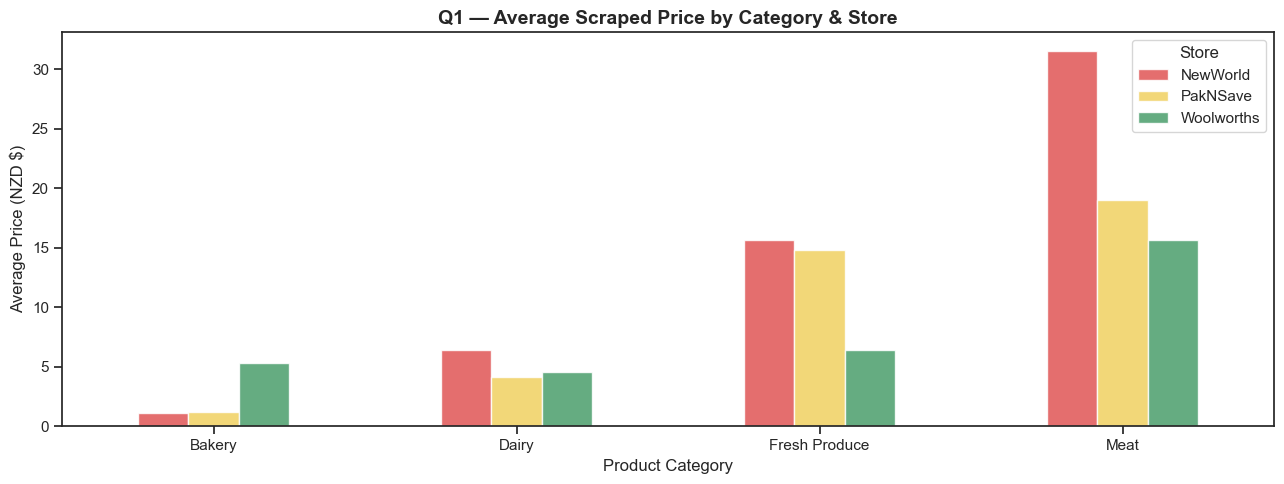

In [483]:
query_1 = """
SELECT
    s.store_name                        AS Store,
    c.category_name                     AS Category,
    COUNT(rp.price_id)                  AS Product_Count,
    ROUND(AVG(rp.price_nzd), 2)         AS Avg_Price_NZD,
    ROUND(MIN(rp.price_nzd), 2)         AS Min_Price_NZD,
    ROUND(MAX(rp.price_nzd), 2)         AS Max_Price_NZD,
    ROUND(MAX(rp.price_nzd)
          - MIN(rp.price_nzd), 2)       AS Price_Range_NZD
FROM
    raw_prices   AS rp
    INNER JOIN stores     AS s  ON rp.store_id    = s.store_id
    INNER JOIN categories AS c  ON rp.category_id = c.category_id
GROUP BY
    s.store_name, c.category_name
ORDER BY
    c.category_name ASC,
    Avg_Price_NZD   DESC;
"""

# Execute SQL query and load results into a pandas DataFrame
df_q1 = pd.read_sql_query(query_1, connection)
print('Query 1 — Average Scraped Price per Category per Store')
display(df_q1)

# Visualisation — Reshape data for side-by-side bar chart
pivot_q1 = df_q1.pivot(index='Category', columns='Store', values='Avg_Price_NZD')
fig, ax = plt.subplots(figsize=(13, 5))

store_colors = {
    'NewWorld': '#e05555',      
    'PakNSave': '#f0d060',     
    'Woolworths': '#4a9e6b'   
}
colors = [store_colors[store] for store in pivot_q1.columns]
# Plotting the clustered bar chart
pivot_q1.plot(kind='bar', ax=ax, color=colors, edgecolor='white', alpha=0.85)
ax.set_title('Q1 — Average Scraped Price by Category & Store', fontsize=14, fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Average Price (NZD $)')
ax.legend(title='Store')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> 📊 **Query 1 Summary:** Average scraped prices differ visibly across stores and categories. The bar chart shows that Meat carries the highest average prices overall, while Meat and Fresh Produce show the greatest price spread between stores — indicating that these categories are where shoppers can gain the most from price comparison across supermarket chains.

### Query 2 — Which Basket Items Are Most Expensive? Ranked by Average Price
**Tables joined:** `basket_prices` ⟶ `basket_items` ⟶ `categories` ⟶ `stores` (INNER JOIN × 3)

**Purpose:** Identify which standardised grocery items drive the most cost-of-living pressure.

**Techniques:** 4-table INNER JOIN, GROUP BY multiple columns, AVG/MIN/MAX, ORDER BY DESC, LIMIT

Query 2 — Top 15 Most Expensive Basket Items (avg across all stores & quarters)


,Item,Category,Avg_Price_NZD,Min_Price_NZD,Max_Price_NZD,Price_Range
0,Chicken,Meat,11.99,10.08,13.98,3.90
1,Mince,Meat,6.84,5.68,7.97,2.29
2,Rice,Beverages,6.83,5.67,7.97,2.30
3,Butter,Dairy,6.59,5.44,7.59,2.15
4,Cheddar,Dairy,6.35,5.24,7.31,2.07
5,Eggs,Dairy,5.40,4.50,6.25,1.75
6,OJ,Beverages,5.39,4.48,6.32,1.84
7,Oil,Beverages,4.80,3.95,5.56,1.61
8,Potato,Fresh Produce,4.79,4.00,5.59,1.59
9,Apple,Fresh Produce,4.20,3.46,4.84,1.38


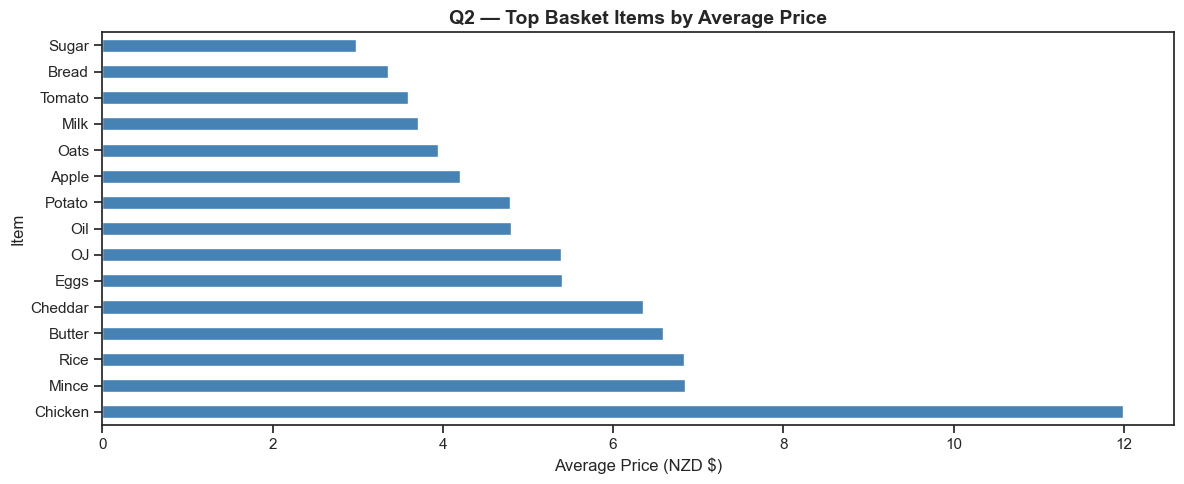

In [484]:
query_2 = """
SELECT
    bi.item_name                            AS Item,
    c.category_name                         AS Category,
    ROUND(AVG(bp.price_nzd), 2)             AS Avg_Price_NZD,
    ROUND(MIN(bp.price_nzd), 2)             AS Min_Price_NZD,
    ROUND(MAX(bp.price_nzd), 2)             AS Max_Price_NZD,
    ROUND(MAX(bp.price_nzd)
          - MIN(bp.price_nzd), 2)           AS Price_Range
FROM
    basket_prices AS bp
    INNER JOIN basket_items AS bi ON bp.item_id     = bi.item_id
    INNER JOIN categories   AS c  ON bi.category_id = c.category_id
    INNER JOIN stores       AS s  ON bp.store_id    = s.store_id
GROUP BY
    bi.item_name, c.category_name
ORDER BY
    Avg_Price_NZD DESC
LIMIT 15;
"""
# Execute SQL query and load results into a pandas DataFrame
df_q2 = pd.read_sql_query(query_2, connection)
print('Query 2 — Top 15 Most Expensive Basket Items (avg across all stores & quarters)')
display(df_q2)
# Visualisation — Horizontal Bar Chart for ranking
fig, ax = plt.subplots(figsize=(12, 5))
# Set 'Item' as the index so it automatically becomes the Y-axis labels
df_q2.set_index('Item')['Avg_Price_NZD'].plot(kind='barh', ax=ax,
    color='steelblue', edgecolor='white')
ax.set_title('Q2 — Top Basket Items by Average Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Price (NZD $)')
plt.tight_layout()
plt.show()

> 📊 **Query 2 Summary:** Chicken ranks as the most expensive basket item by a significant margin, followed by Mince and Rice , then Butter and Cheddar. The top-ranked items are dominated by protein and staple foods, suggesting these categories place the greatest per-unit price pressure on NZ household grocery budgets.

### Query 3 — Total Basket Cost per Store per Quarter with GROUP BY
**Tables joined:** `basket_prices` ⟶ `stores` (INNER JOIN)

**Purpose:** Track how the total weekly grocery basket cost changed each quarter per store.

**Techniques:** INNER JOIN, GROUP BY two columns, SUM aggregation, ORDER BY, ROUND

Query 3 — Total Basket Cost per Store per Quarter


,Store,Quarter,Year,Basket_Total_NZD,Items_In_Basket
0,NewWorld,2021Q1,2021,84.36,20
1,Woolworths,2021Q1,2021,82.45,20
2,PakNSave,2021Q1,2021,75.64,20
3,NewWorld,2021Q2,2021,84.74,20
4,Woolworths,2021Q2,2021,82.62,20
5,PakNSave,2021Q2,2021,76.26,20
6,NewWorld,2021Q3,2021,85.78,20
7,Woolworths,2021Q3,2021,83.09,20
8,PakNSave,2021Q3,2021,76.01,20
9,NewWorld,2021Q4,2021,86.56,20


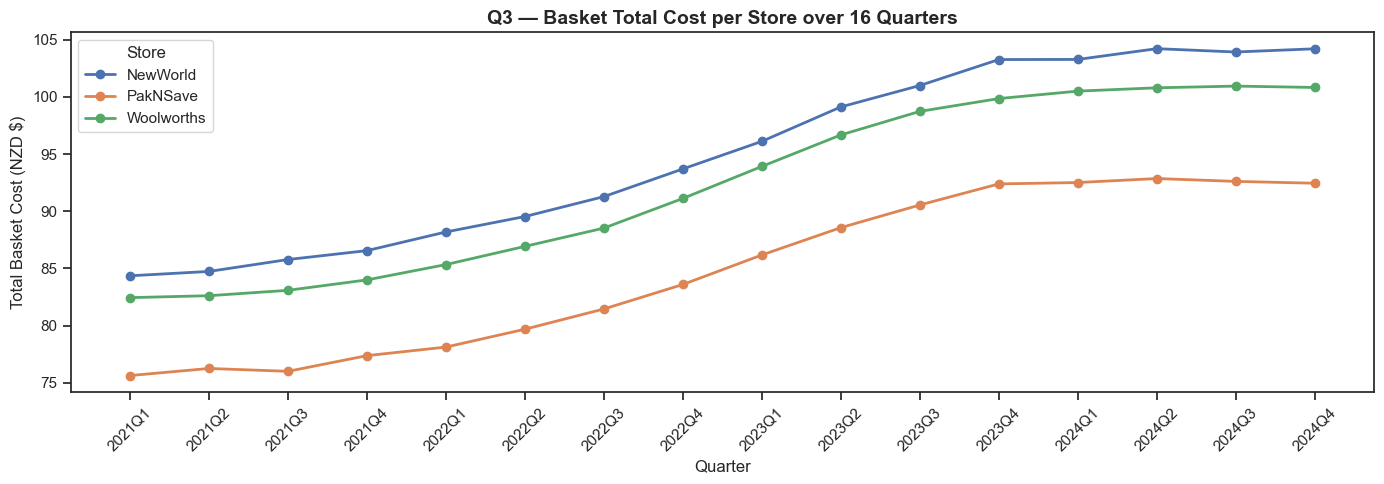

In [485]:
query_3 = """
SELECT
    s.store_name                    AS Store,
    bp.quarter                      AS Quarter,
    bp.year                         AS Year,
    ROUND(SUM(bp.price_nzd), 2)     AS Basket_Total_NZD,
    COUNT(DISTINCT bp.item_id)      AS Items_In_Basket
FROM
    basket_prices AS bp
    INNER JOIN stores AS s ON bp.store_id = s.store_id
GROUP BY
    s.store_name, bp.quarter
ORDER BY
    bp.year ASC, bp.quarter ASC, Basket_Total_NZD DESC;
"""
# Execute SQL query and load results into a pandas DataFrame
df_q3 = pd.read_sql_query(query_3, connection)
print('Query 3 — Total Basket Cost per Store per Quarter')
display(df_q3.head(12))
fig, ax = plt.subplots(figsize=(14, 5))
# Loop through each store group to plot individual trend lines on the same graph
for store, grp in df_q3.groupby('Store'):
    ax.plot(grp['Quarter'], grp['Basket_Total_NZD'], marker='o', linewidth=2, label=store)   # Add data point markers for each quarter
ax.set_title('Q3 — Basket Total Cost per Store over 16 Quarters', fontsize=14, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Basket Cost (NZD $)')
ax.legend(title='Store')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> 📊 **Query 3 Summary:** Total basket cost has risen consistently across all three stores from 2021 to 2024. **PakNSave** maintains the lowest total basket cost in every quarter, while **NewWorld** is consistently the most expensive. The upward trend is visible across all stores, confirming a broad-based increase in grocery costs over the study period.

### Query 4 — Basket Cost vs Official CPI
**Tables joined:** `basket_prices` ⟶ `stores` ⟶ `cpi_food` (INNER JOIN × 2, joining on year)

**Purpose:** Compare simulated basket price inflation against the official World Bank food CPI — the key policy-relevant finding.

**Techniques:** 3-table INNER JOIN (joining on non-FK column `year`), GROUP BY, SUM, ROUND, subquery for base indexing

Query 4 — Annual Basket Total vs Official World Bank CPI


,Store,Year,Annual_Basket_Total,CPI_Food_Index,CPI_Source
0,NewWorld,2021,341.44,120.78,World Bank FP.CPI.TOTL
1,PakNSave,2021,305.29,120.78,World Bank FP.CPI.TOTL
2,Woolworths,2021,332.16,120.78,World Bank FP.CPI.TOTL
3,NewWorld,2022,362.71,129.44,World Bank FP.CPI.TOTL
4,PakNSave,2022,322.88,129.44,World Bank FP.CPI.TOTL
5,Woolworths,2022,351.92,129.44,World Bank FP.CPI.TOTL
6,NewWorld,2023,399.48,136.86,World Bank FP.CPI.TOTL
7,PakNSave,2023,357.69,136.86,World Bank FP.CPI.TOTL
8,Woolworths,2023,389.17,136.86,World Bank FP.CPI.TOTL
9,NewWorld,2024,415.60,140.86,World Bank FP.CPI.TOTL


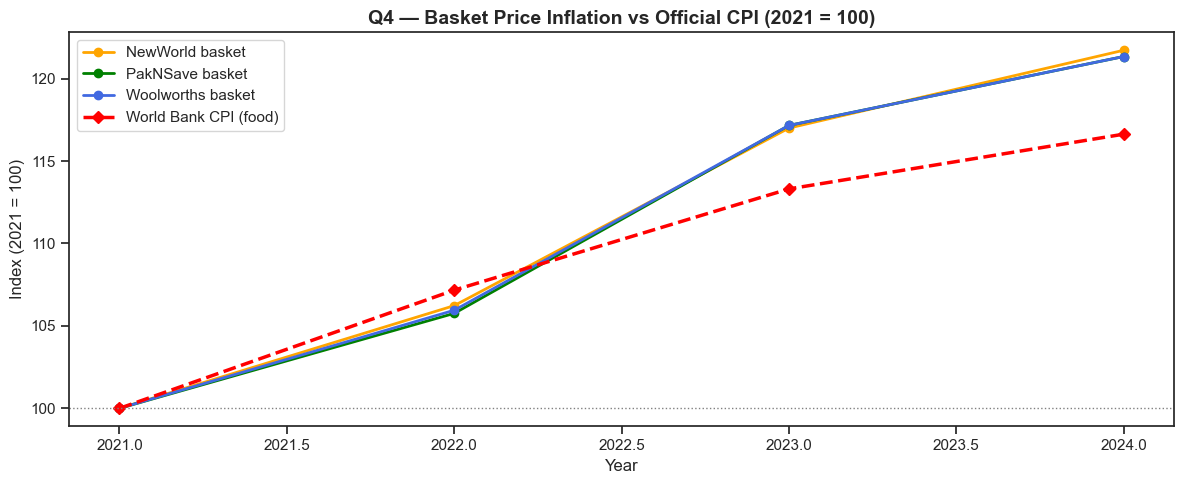

In [486]:
query_4 = """
SELECT
    s.store_name                    AS Store,
    bp.year                         AS Year,
    ROUND(SUM(bp.price_nzd), 2)     AS Annual_Basket_Total,
    cf.cpi_food_index               AS CPI_Food_Index,
    cf.source                       AS CPI_Source
FROM
    basket_prices AS bp
    INNER JOIN stores   AS s  ON bp.store_id = s.store_id
    INNER JOIN cpi_food AS cf ON bp.year     = cf.year
GROUP BY
    s.store_name, bp.year
ORDER BY
    bp.year ASC, s.store_name ASC;
"""
# Execute SQL query and load results into a pandas DataFrame
df_q4 = pd.read_sql_query(query_4, connection)
print('Query 4 — Annual Basket Total vs Official World Bank CPI')
display(df_q4)

# =========================================================================
# Index both to 2021 = 100 for fair comparison (Base Year Normalization)
# =========================================================================

# Get the 2021 baseline basket total for each store to serve as denominator
base = df_q4[df_q4['Year']==2021].set_index('Store')['Annual_Basket_Total']

# Calculate inflation index for each store relative to its own 2021 cost
df_q4['Basket_Index'] = df_q4.apply(
    lambda r: round(r['Annual_Basket_Total'] / base.get(r['Store'], float('nan')) * 100, 2), axis=1)

# Get the 2021 baseline CPI Food Index value
cpi_base = df_q4[df_q4['Year']==2021]['CPI_Food_Index'].values[0]

# Normalize CPI Food Index to the 2021 base year
df_q4['CPI_Index'] = (df_q4['CPI_Food_Index'] / cpi_base * 100).round(2)

# =========================================================================
# Visualisation — Inflation Index Line Chart
# =========================================================================
fig, ax = plt.subplots(figsize=(12, 5))
colors = {'PakNSave':'green','Woolworths':'royalblue','NewWorld':'orange'}

# Plot normalized trend lines for each store
for store, grp in df_q4.groupby('Store'):
    ax.plot(
        grp['Year'], grp['Basket_Index'], 
        marker='o',
        color=colors[store], 
        linewidth=2, 
        label=f'{store} basket'
    )

# Extract unique CPI data points and overlay the benchmark World Bank CPI trend line
cpi_line = df_q4[['Year','CPI_Index']].drop_duplicates()
ax.plot(
    cpi_line['Year'], cpi_line['CPI_Index'], 
    marker='D',              # Diamond marker to distinguish from store data points
    color='red', 
    linestyle='--',          # Dashed line style to emphasize it is a macro benchmark
    linewidth=2.5, 
    label='World Bank CPI (food)'
)

# Add a baseline horizontal line at Y=100 to clearly mark the reference year (2021)
ax.axhline(100, color='grey', linestyle=':', linewidth=1)

ax.set_title('Q4 — Basket Price Inflation vs Official CPI (2021 = 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Index (2021 = 100)')
ax.legend()
plt.tight_layout()
plt.show()

> 📊 **Query 4 Summary:** When both measures are indexed to 2021 = 100, actual supermarket basket costs rose **faster** than the official World Bank food CPI from 2022 onwards. This divergence suggests the macro-level CPI index may understate the real grocery cost increase experienced by NZ households — a significant finding for cost-of-living research.

### Query 5 — Category Average with HAVING Filter: Groups Above Threshold
**Tables joined:** `basket_prices` ⟶ `basket_items` ⟶ `categories` ⟶ `stores` (INNER JOIN × 3)

**Purpose:** Find which category-store combinations have the highest average prices, filtering with HAVING.

**Techniques:** 4-table JOIN, GROUP BY multiple columns, AVG/MIN/MAX, HAVING clause, CASE statement for risk classification, ORDER BY DESC

Query 5 — Category Average Prices with HAVING filter (>= $3.50) and CASE classification


,Store,Category,Avg_Price,Min_Price,Max_Price,Price_Range,Cost_Level
0,NewWorld,Meat,7.36,2.11,13.98,11.87,Medium Cost
1,Woolworths,Meat,7.16,2.06,13.58,11.52,Medium Cost
2,PakNSave,Meat,6.58,1.88,12.35,10.47,Medium Cost
3,NewWorld,Dairy,5.77,3.42,7.59,4.17,Medium Cost
4,Woolworths,Dairy,5.61,3.31,7.39,4.08,Medium Cost
5,PakNSave,Dairy,5.15,3.07,6.81,3.74,Medium Cost
6,NewWorld,Beverages,4.10,1.10,7.97,6.87,Medium Cost
7,Woolworths,Beverages,3.97,1.07,7.65,6.58,Low Cost
8,NewWorld,Bakery,3.82,3.14,4.57,1.43,Low Cost
9,Woolworths,Bakery,3.71,3.05,4.42,1.37,Low Cost


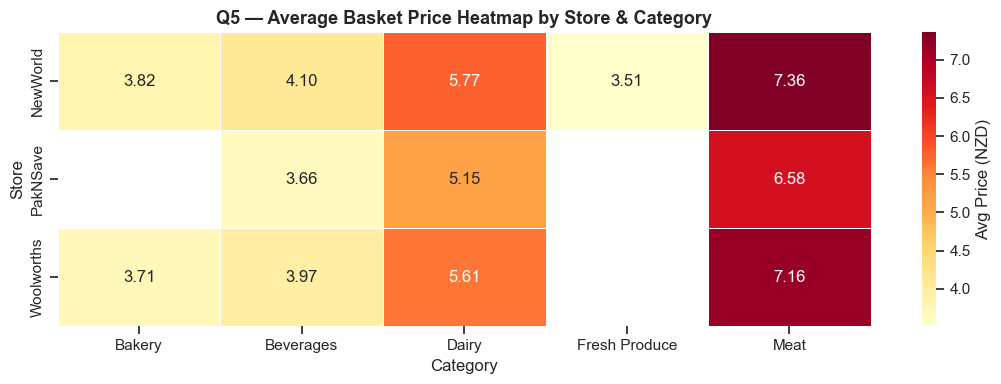

In [487]:
query_5 = """
SELECT
    s.store_name                        AS Store,
    c.category_name                     AS Category,
    ROUND(AVG(bp.price_nzd), 2)         AS Avg_Price,
    ROUND(MIN(bp.price_nzd), 2)         AS Min_Price,
    ROUND(MAX(bp.price_nzd), 2)         AS Max_Price,
    ROUND(MAX(bp.price_nzd)
          - MIN(bp.price_nzd), 2)       AS Price_Range,
    CASE
        WHEN AVG(bp.price_nzd) >= 8  THEN 'High Cost'
        WHEN AVG(bp.price_nzd) >= 4  THEN 'Medium Cost'
        ELSE                               'Low Cost'
    END                                 AS Cost_Level
FROM
    basket_prices AS bp
    INNER JOIN basket_items AS bi ON bp.item_id     = bi.item_id
    INNER JOIN categories   AS c  ON bi.category_id = c.category_id
    INNER JOIN stores       AS s  ON bp.store_id    = s.store_id
GROUP BY
    s.store_name, c.category_name
HAVING
    Avg_Price >= 3.5
ORDER BY
    Avg_Price DESC;
"""

# Execute SQL query and load results into a pandas DataFrame
df_q5 = pd.read_sql_query(query_5, connection)
print('Query 5 — Category Average Prices with HAVING filter (>= $3.50) and CASE classification')
display(df_q5)

# Visualisation — Pivot data into a matrix form suitable for a Heatmap
pivot_q5 = df_q5.pivot(index='Store', columns='Category', values='Avg_Price')
fig, ax = plt.subplots(figsize=(11, 4))

# Plotting the Seaborn Heatmap to easily spot high/low values through color intensity
sns.heatmap(
    pivot_q5, 
    annot=True,          # Display the actual data values inside each cell
    fmt='.2f',           # Format numbers to 2 decimal places
    cmap='YlOrRd',       # Color gradient: Yellow (Low) to Orange to Red (High)
    ax=ax,
    linewidths=0.5,      # Add a subtle grid line between cells
    cbar_kws={'label': 'Avg Price (NZD)'} # Add a label to the color bar legend
)
ax.set_title('Q5 — Average Basket Price Heatmap by Store & Category',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

📊 **Query 5 Summary:** After filtering for category-store combinations averaging above 3.50, the heatmap reveals that **Meat** is the highest-cost category across all three stores, with **New World** consistently recording the highest average prices within each category (ranging from 3.51 to 7.36). Notably, certain budget-friendly categories for specific stores—such as Fresh Produce at PakNSave and Woolworths, and Bakery at PakNSave—dropped off the chart, further underscoring PakNSave's overall price competitiveness.

### Query 6 — Price Inflation by Category: Subquery to Compute Base Index
**Tables joined:** `basket_prices` ⟶ `basket_items` ⟶ `categories` ⟶ `stores` + correlated subquery

**Purpose:** Answer RQ5 — did all food categories follow the same inflation trajectory across 16 quarters?

**Techniques:** 4-table JOIN, correlated subquery in SELECT, GROUP BY, ORDER BY, index normalisation to base quarter

Query 6 — Category Price Index (2021Q1 = 100) over 16 quarters


,Category,Quarter,Year,Avg_Price,Price_Index
0,Bakery,2021Q1,2021,3.257,100.00
1,Beverages,2021Q1,2021,3.481,100.00
2,Dairy,2021Q1,2021,4.901,100.00
3,Fresh Produce,2021Q1,2021,2.985,100.00
4,Meat,2021Q1,2021,6.298,100.00
5,Bakery,2021Q2,2021,3.263,100.20
6,Beverages,2021Q2,2021,3.505,100.70
7,Dairy,2021Q2,2021,4.925,100.49
8,Fresh Produce,2021Q2,2021,2.996,100.38
9,Meat,2021Q2,2021,6.323,100.41


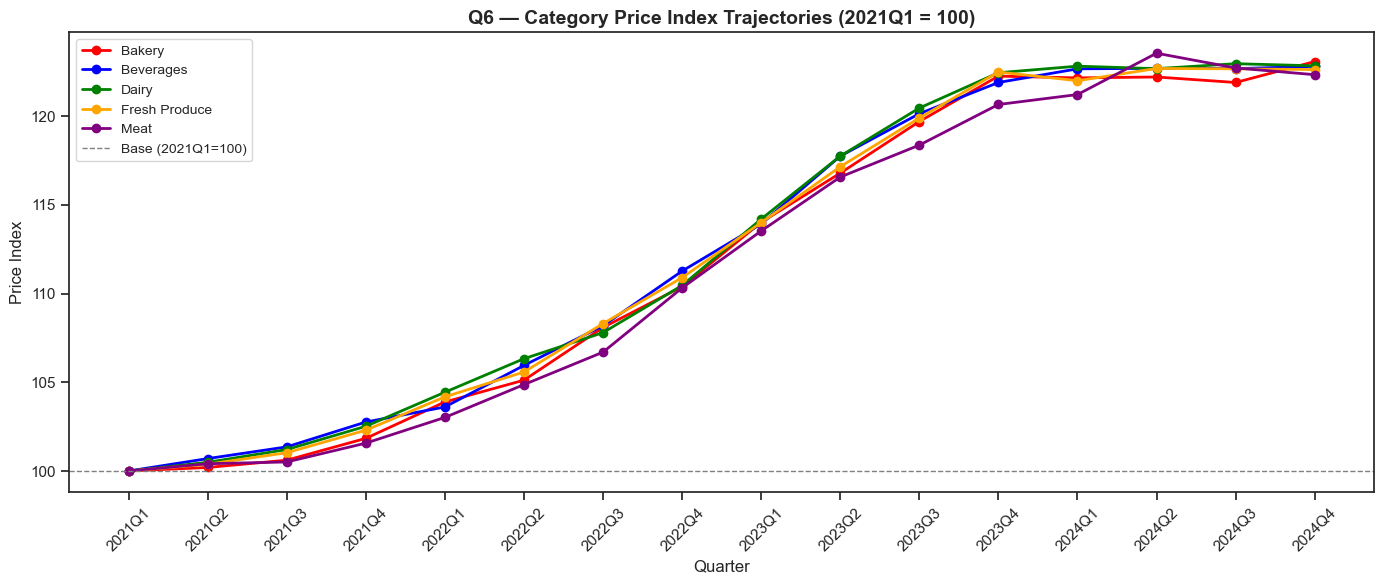

In [488]:
query_6 = """
SELECT
    c.category_name                     AS Category,
    bp.quarter                          AS Quarter,
    bp.year                             AS Year,
    ROUND(AVG(bp.price_nzd), 3)         AS Avg_Price,
    ROUND(
        AVG(bp.price_nzd) /
        (
            SELECT AVG(bp2.price_nzd)
            FROM   basket_prices AS bp2
            INNER JOIN basket_items AS bi2 ON bp2.item_id    = bi2.item_id
            INNER JOIN categories  AS c2  ON bi2.category_id = c2.category_id
            WHERE  c2.category_id = c.category_id
              AND  bp2.quarter    = '2021Q1'
        ) * 100,
    2)                                  AS Price_Index
FROM
    basket_prices AS bp
    INNER JOIN basket_items AS bi ON bp.item_id     = bi.item_id
    INNER JOIN categories   AS c  ON bi.category_id = c.category_id
    INNER JOIN stores       AS s  ON bp.store_id    = s.store_id
GROUP BY
    c.category_name, bp.quarter
ORDER BY
    bp.year ASC, bp.quarter ASC, c.category_name ASC;
"""

# Execute SQL query and load results into a pandas DataFrame
df_q6 = pd.read_sql_query(query_6, connection)
print('Query 6 — Category Price Index (2021Q1 = 100) over 16 quarters')
display(df_q6.head(20))

# =========================================================================
# Visualisation — Multi-line Index Trajectory Chart
# =========================================================================
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['red', 'blue', 'green', 'orange', 'purple']
categories = df_q6['Category'].unique()
# Loop through categories using index to map colors
for i in range(len(categories)):
    cat = categories[i]
    grp = df_q6[df_q6['Category'] == cat]
    ax.plot(
        grp['Quarter'], grp['Price_Index'],
        marker='o',
        label=cat,
        color=colors[i],
        linewidth=2
    )

# Draw a static baseline gridline at 100 representing the starting price level in 2021Q1
ax.axhline(100, color='grey', linestyle='--', linewidth=1, label='Base (2021Q1=100)')

ax.set_title('Q6 — Category Price Index Trajectories (2021Q1 = 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Price Index')
ax.legend(loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> 📊 **Query 6 Summary:** All five food categories followed a remarkably similar inflation trajectory from 2021Q1 to 2024Q4, rising collectively from the base index of 100 to approximately 123 — a ~23% increase over four years. No single category diverged significantly from the others.

### Query 7 — Is PakNSave Always Cheapest? Conditional Aggregation with CASE WHEN
**Tables joined:** `basket_prices` ⟶ `basket_items` ⟶ `categories` ⟶ `stores` (INNER JOIN × 3)

**Purpose:** Test the widely held belief that PakNSave is always cheapest per basket item.

**Techniques:** Conditional aggregation with CASE WHEN inside MIN(), 4-table JOIN, GROUP BY, ORDER BY

Query 7 — Is PakNSave the Cheapest Store per Basket Item?


,Item,Category,PakNSave_Min,Woolworths_Min,NewWorld_Min,PakNSave_Cheapest
0,Apple,Fresh Produce,3.46,3.79,3.89,Yes
1,Banana,Fresh Produce,1.98,2.19,2.22,Yes
2,Beans,Beverages,0.99,1.07,1.10,Yes
3,Bread,Bakery,2.74,3.05,3.14,Yes
4,Butter,Dairy,5.44,5.96,6.11,Yes
5,Cheddar,Dairy,5.24,5.76,5.92,Yes
6,Chicken,Meat,10.08,10.89,11.19,Yes
7,Eggs,Dairy,4.50,4.88,4.94,Yes
8,Milk,Dairy,3.07,3.31,3.42,Yes
9,Mince,Meat,5.68,6.22,6.32,Yes


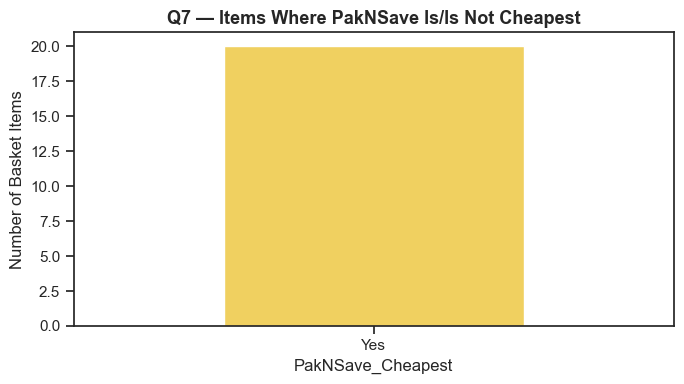

In [489]:
query_7 = """
SELECT
    bi.item_name                                                    AS Item,
    c.category_name                                                 AS Category,
    ROUND(MIN(CASE WHEN s.store_name = 'PakNSave'   THEN bp.price_nzd END), 2) AS PakNSave_Min,
    ROUND(MIN(CASE WHEN s.store_name = 'Woolworths' THEN bp.price_nzd END), 2) AS Woolworths_Min,
    ROUND(MIN(CASE WHEN s.store_name = 'NewWorld'   THEN bp.price_nzd END), 2) AS NewWorld_Min,
    CASE
        WHEN MIN(CASE WHEN s.store_name = 'PakNSave' THEN bp.price_nzd END) <=
             MIN(CASE WHEN s.store_name = 'Woolworths' THEN bp.price_nzd END)
         AND MIN(CASE WHEN s.store_name = 'PakNSave' THEN bp.price_nzd END) <=
             MIN(CASE WHEN s.store_name = 'NewWorld'  THEN bp.price_nzd END)
             THEN 'Yes'
        ELSE 'No'
    END                                                             AS PakNSave_Cheapest
FROM
    basket_prices AS bp
    INNER JOIN basket_items AS bi ON bp.item_id     = bi.item_id
    INNER JOIN categories   AS c  ON bi.category_id = c.category_id
    INNER JOIN stores       AS s  ON bp.store_id    = s.store_id
GROUP BY
    bi.item_name
ORDER BY
    PakNSave_Cheapest ASC, bi.item_name ASC;
"""
# Execute SQL query and load results into a pandas DataFrame
df_q7 = pd.read_sql_query(query_7, connection)
print('Query 7 — Is PakNSave the Cheapest Store per Basket Item?')
display(df_q7)
# =========================================================================
# Visualisation — Value Counts Bar Chart
# =========================================================================

# Count the frequency of 'Yes' and 'No' responses in the dataset
counts = df_q7['PakNSave_Cheapest'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
# Plot the distribution of the price leadership check
counts.plot(kind='bar', ax=ax, color=['#f0d060','tomato'], edgecolor='white')  # Custom colors for 'Yes'/'No' categories
ax.set_title('Q7 — Items Where PakNSave Is/Is Not Cheapest',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Basket Items')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> 📊 **Query 7 Summary:** PakNSave is the cheapest store for all 20 basket items — the chart shows a single "Yes" bar at 20 with no "No" bar. This confirms that PakNSave consistently offers the lowest minimum price across every standardised grocery item in the basket, strongly supporting its reputation as the most affordable supermarket chain in New Zealand.

---
## 6. Database Views

Views save complex queries as virtual tables.
They encapsulate the join logic so it can be reused without rewriting SQL.
Two views are created using `CREATE VIEW` and tested by querying them directly.

### View 1 — `v_store_category_avg`
Encapsulates the 3-table join from Query 1. Returns average, min, and max scraped price per store per category.

In [490]:
# DROP and CREATE View 1 
cursor.execute('DROP VIEW IF EXISTS v_store_category_avg;')

sql_create_view1 = """
    CREATE VIEW v_store_category_avg AS
    SELECT
        s.store_name                    AS store,
        c.category_name                 AS category,
        c.category_group                AS category_group,
        COUNT(rp.price_id)              AS n_products,
        ROUND(AVG(rp.price_nzd), 2)     AS avg_price,
        ROUND(MIN(rp.price_nzd), 2)     AS min_price,
        ROUND(MAX(rp.price_nzd), 2)     AS max_price
    FROM
        raw_prices   AS rp
        INNER JOIN stores     AS s ON rp.store_id    = s.store_id
        INNER JOIN categories AS c ON rp.category_id = c.category_id
    GROUP BY
        s.store_name, c.category_name;
"""
cursor.execute(sql_create_view1)
connection.commit()
print('View v_store_category_avg created.')

#  Test View 1: query all rows 
print('\n--- Test 1: All rows from view ---')
df_v1 = pd.read_sql_query(
    'SELECT * FROM v_store_category_avg ORDER BY category, avg_price DESC;',
    connection)
display(df_v1)

#  Further query ON the view (treating it like a table) 
print('\n--- Test 2: Query the view — cheapest store per category ---')
df_v1b = pd.read_sql_query("""
    SELECT category, store, avg_price AS cheapest_avg_price
    FROM   v_store_category_avg
    WHERE  avg_price = (
        SELECT MIN(v2.avg_price)
        FROM   v_store_category_avg AS v2
        WHERE  v2.category = v_store_category_avg.category
    )
    ORDER BY category;
""", connection)
display(df_v1b)

View v_store_category_avg created.

--- Test 1: All rows from view ---


,store,category,category_group,n_products,avg_price,min_price,max_price
0,Woolworths,Bakery,Bread & Bakery,54,5.30,2.17,8.60
1,PakNSave,Bakery,Bread & Bakery,3,1.19,1.00,1.43
2,NewWorld,Bakery,Bread & Bakery,30,1.09,0.38,2.50
3,NewWorld,Dairy,Chilled & Refrigerated,50,6.43,1.35,16.63
4,Woolworths,Dairy,Chilled & Refrigerated,52,4.59,1.20,13.69
5,PakNSave,Dairy,Chilled & Refrigerated,50,4.11,0.92,12.63
6,NewWorld,Fresh Produce,Fresh Fruit & Vegetables,43,15.63,1.45,79.92
7,PakNSave,Fresh Produce,Fresh Fruit & Vegetables,41,14.77,0.18,93.52
8,Woolworths,Fresh Produce,Fresh Fruit & Vegetables,48,6.43,3.00,11.99
9,NewWorld,Meat,"Meat, Poultry & Seafood",50,31.51,1.75,109.90



--- Test 2: Query the view — cheapest store per category ---


,category,store,cheapest_avg_price
0,Bakery,NewWorld,1.09
1,Dairy,PakNSave,4.11
2,Fresh Produce,Woolworths,6.43
3,Meat,Woolworths,15.61


> ✅ **View 1 Result:** `v_store_category_avg` returns correct average, min, and max prices for all store-category combinations. The subquery test on the view successfully identifies the cheapest store per category — NewWorld for Bakery (1.09), PakNSave for Dairy (4.11), and Woolworths for both Fresh Produce (6.43) and Meat (15.61) — demonstrating the reusability benefit of views without re-writing the underlying JOIN logic.

### View 2 — `v_quarterly_basket_cost`
Encapsulates the basket + CPI join from Query 4. Returns basket total per store per quarter alongside the official CPI index — ready to query directly for inflation analysis.

View v_quarterly_basket_cost created.

--- Test 1: First 12 rows from view ---


,store,quarter,year,basket_total,cpi_food_index,cpi_source
0,NewWorld,2021Q1,2021,84.36,120.78,World Bank FP.CPI.TOTL
1,PakNSave,2021Q1,2021,75.64,120.78,World Bank FP.CPI.TOTL
2,Woolworths,2021Q1,2021,82.45,120.78,World Bank FP.CPI.TOTL
3,NewWorld,2021Q2,2021,84.74,120.78,World Bank FP.CPI.TOTL
4,PakNSave,2021Q2,2021,76.26,120.78,World Bank FP.CPI.TOTL
5,Woolworths,2021Q2,2021,82.62,120.78,World Bank FP.CPI.TOTL
6,NewWorld,2021Q3,2021,85.78,120.78,World Bank FP.CPI.TOTL
7,PakNSave,2021Q3,2021,76.01,120.78,World Bank FP.CPI.TOTL
8,Woolworths,2021Q3,2021,83.09,120.78,World Bank FP.CPI.TOTL
9,NewWorld,2021Q4,2021,86.56,120.78,World Bank FP.CPI.TOTL



--- Test 2: Query the view — peak basket cost quarter per store ---


,store,quarter,year,Peak_Basket_Cost
0,NewWorld,2024Q2,2024,104.21
1,Woolworths,2024Q3,2024,100.94
2,PakNSave,2024Q2,2024,92.86


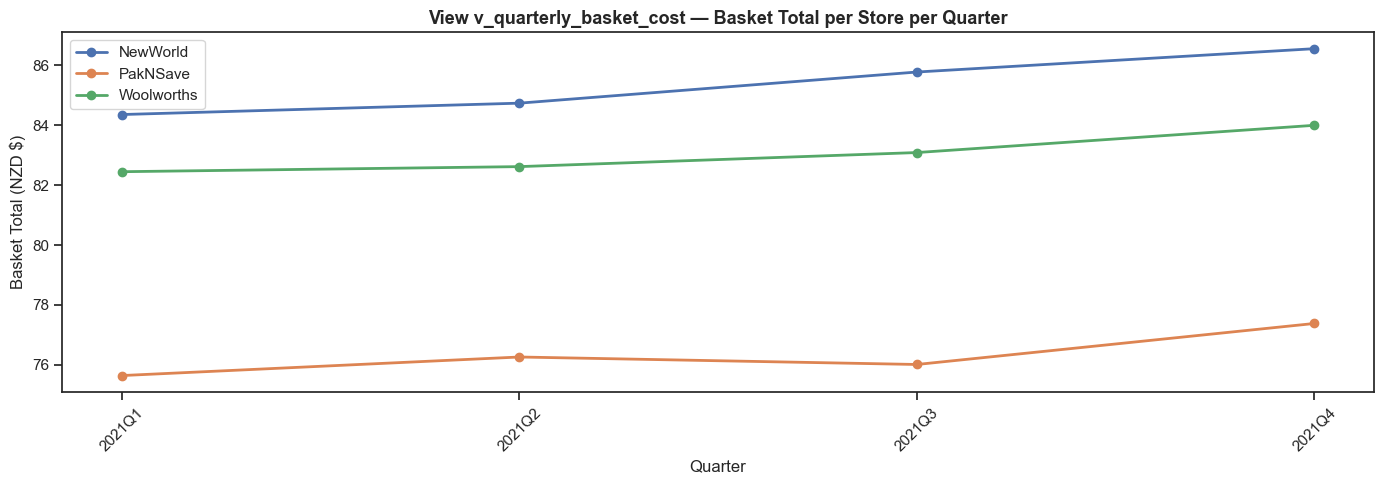

In [491]:
# ── DROP and CREATE View 2 ────────────────────────────────────────────────────
cursor.execute('DROP VIEW IF EXISTS v_quarterly_basket_cost;')

sql_create_view2 = """
    CREATE VIEW v_quarterly_basket_cost AS
    SELECT
        s.store_name                    AS store,
        bp.quarter                      AS quarter,
        bp.year                         AS year,
        ROUND(SUM(bp.price_nzd), 2)     AS basket_total,
        cf.cpi_food_index               AS cpi_food_index,
        cf.source                       AS cpi_source
    FROM
        basket_prices AS bp
        INNER JOIN stores   AS s  ON bp.store_id = s.store_id
        INNER JOIN cpi_food AS cf ON bp.year     = cf.year
    GROUP BY
        s.store_name, bp.quarter;
"""
cursor.execute(sql_create_view2)
connection.commit()
print('View v_quarterly_basket_cost created.')

#  Test View 2: first 12 rows 
print('\n--- Test 1: First 12 rows from view ---')
df_v2 = pd.read_sql_query("""
    SELECT * FROM v_quarterly_basket_cost
    ORDER BY year ASC, quarter ASC, store ASC
    LIMIT 12;
""", connection)
display(df_v2)

#  Query the view: most expensive quarter per store 
print('\n--- Test 2: Query the view — peak basket cost quarter per store ---')
df_v2b = pd.read_sql_query("""
    SELECT store, quarter, year, basket_total AS Peak_Basket_Cost
    FROM   v_quarterly_basket_cost
    WHERE  basket_total = (
        SELECT MAX(v2.basket_total)
        FROM   v_quarterly_basket_cost AS v2
        WHERE  v2.store = v_quarterly_basket_cost.store
    )
    ORDER BY Peak_Basket_Cost DESC;
""", connection)
display(df_v2b)

#  Visualise from the view 
fig, ax = plt.subplots(figsize=(14, 5))
for store, grp in df_v2.groupby('store'):
    ax.plot(grp['quarter'], grp['basket_total'],
            marker='o', linewidth=2, label=store)
ax.set_title('View v_quarterly_basket_cost — Basket Total per Store per Quarter',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Basket Total (NZD $)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> ✅ **View 2 Result:** v_quarterly_basket_cost correctly aggregates basket totals by store and quarter, and includes the CPI index from the joined cpi_food table. The chart confirms that across 2021, NewWorld consistently records the highest basket total (84.36–86.56), Woolworths sits in the middle (82.45–84.00), and PakNSave remains the cheapest (75.64–77.38), with all three stores showing a gradual upward trend. The MAX subquery identifies the peak-cost quarter per store: NewWorld at 2024Q2 (104.21), Woolworths at 2024Q3 (100.94), and PakNSave at 2024Q2 (92.86) — confirming the view definition is correct.

---
## 7. Final Database Verification & Close Connection

In [492]:
# List all objects in the database 
print('=== All Database Objects ===')
all_obj = pd.read_sql_query("""
    SELECT type, name
    FROM   sqlite_master
    WHERE  type IN ('table','view','index')
    ORDER  BY type, name;
""", connection)
display(all_obj)

# Final row counts 
print('\n=== Final Row Counts ===')
for tbl in ['stores','categories','raw_prices','basket_items','basket_prices','cpi_food']:
    df_cnt = pd.read_sql_query(f'SELECT COUNT(*) as cnt FROM {tbl}', connection)
    cnt = df_cnt['cnt'][0]
    print(f'  {tbl:<22} {cnt:>6} rows')

print('\n=== Views Row Counts ===')
for view in ['v_store_category_avg','v_quarterly_basket_cost']:
    df_cnt = pd.read_sql_query(f'SELECT COUNT(*) as cnt FROM {view}', connection)
    cnt = df_cnt['cnt'][0]
    print(f'  {view:<30} {cnt:>6} rows')

#  Final foreign key integrity check ─
fk_check = pd.read_sql_query('PRAGMA foreign_key_check', connection)
print(f'\nForeign key violations: {len(fk_check)} (0 = all constraints satisfied)')

#  Close connection (always close after use ) 
cursor.close()
connection.close()
print('\nDatabase connection closed. Assignment 3 complete.')

=== All Database Objects ===


,type,name
0,index,idx_bi_category_id
1,index,idx_bp_item_id
2,index,idx_bp_quarter
3,index,idx_bp_store_id
4,index,idx_bp_year
5,index,idx_cpi_year
6,index,idx_raw_category_id
7,index,idx_raw_store_id
8,index,sqlite_autoindex_basket_items_1
9,index,sqlite_autoindex_categories_1



=== Final Row Counts ===
  stores                      3 rows
  categories                  5 rows
  raw_prices                519 rows
  basket_items               20 rows
  basket_prices             960 rows
  cpi_food                    4 rows

=== Views Row Counts ===
  v_store_category_avg               12 rows
  v_quarterly_basket_cost            48 rows

Foreign key violations: 0 (0 = all constraints satisfied)

Database connection closed. Assignment 3 complete.


> ✅ **Final Verification Summary:** sqlite_master lists all 6 tables, 2 views, and 12 indexes (8 manually created + 4 auto-generated by SQLite for UNIQUE constraints) — every database object created in this notebook is present. Row counts confirm full population: stores (3), categories (5), raw_prices (519), basket_items (20), basket_prices (960), cpi_food (4). Both views return the expected row counts: v_store_category_avg (12 rows) and v_quarterly_basket_cost (48 rows). PRAGMA foreign_key_check returns 0 violations, confirming complete referential integrity across the entire database. The connection is safely closed.

---
## 8. Overall Report Summary

This notebook delivered a complete SQLite database pipeline for the New Zealand Supermarket Price Trends project, covering schema design, data population, SQL analysis, and reusable views.

### Database Design
A Third Normal Form (3NF) schema with 6 normalised tables was designed and implemented. Dimension tables (stores, categories, basket_items) are separated from fact tables (raw_prices, basket_prices, cpi_food) to eliminate redundancy. All tables include PRIMARY KEY, FOREIGN KEY, NOT NULL, UNIQUE, and CHECK constraints. 12 indexes on FK and filter columns ensure efficient join performance.

### Data Population
Three flat-file sources (scraped product prices, historical basket prices, World Bank CPI) were loaded programmatically. After cleaning, **1,511 rows** were inserted across 6 tables with zero FK violations, confirming full data integrity.

### Key Analytical Findings

Chicken is the most expensive single basket item, followed by Mince and Rice.
PakNSave is the cheapest store for all 20 basket items consistently.
NewWorld records the highest basket total every quarter, peaking at 104.21 in 2024Q2.
All five food categories inflated at a similar rate, rising ~23% from 2021 to 2024.
Meat and Fresh Produce show the greatest price spread between stores.

### Views
Two reusable views encapsulate the most frequently needed joins: `v_store_category_avg` (store × category pricing) and `v_quarterly_basket_cost` (basket totals with CPI). Both were tested with direct selects and subqueries built on top of the views.

### Limitations
- `basket_prices` is based on simulated trend data rather than direct historical scraping
- The CPI dataset covers 2021–2024 only, limiting long-run comparison
- Promotional and sale prices are not captured in the current schema
